# EduPulse AI — Final End-to-End Machine Learning Notebook

**Student Success Early-Warning and Intervention Platform**<br>
AI Mini Group Project<br>
Academic prototype localized for a Kabarak University context.<br>
**Student:** Stephen Robert Ochieng Nyambok<br>
**Registration number:** CS/M/0113/01/24<br>
**Unit:** COMP 413 · **Lecturer:** Dr Andrew Kipkebut

This notebook is an executable academic narrative. It uses the real UCI Machine Learning Repository Dataset 697 and the canonical outputs from the reproducible `python -m scripts.train` workflow. It does not claim Kabarak University data, deployment or validation.

## 1. Problem Definition & Objective

Universities may recognize difficulty only after a student's position has deteriorated. The objective is supervised three-class classification of **Dropout**, **Enrolled** and **Graduate** outcomes from information genuinely available at the **end of Semester 1**. Outputs support human review; they must never automate punitive decisions.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = json.loads((ROOT / "artifacts" / "results.json").read_text(encoding="utf-8"))
RESULTS["project"]

{'name': 'EduPulse AI',
 'full_title': 'EduPulse AI: Student Success Early-Warning and Intervention Platform',
 'model_version': '3.0.0',
 'context': 'Academic prototype localized for a Kabarak University context',
 'prediction_point': 'End of Semester 1'}

## 2. Data Acquisition

The source is UCI Dataset 697, *Predict Students' Dropout and Academic Success*, DOI `10.24432/C5MC89`, licensed CC BY 4.0. It describes Portuguese higher education and is not Kabarak University administrative data. The raw local file is treated as immutable and identified by SHA-256 in the training metadata.

In [2]:
from src.data import load_dataset, validate_dataset

raw = load_dataset()
audit = validate_dataset(raw)
audit, raw.shape, raw["Target"].value_counts()

({'rows': 4424,
  'columns': 37,
  'original_feature_count': 36,
  'duplicates': 0,
  'missing_cells': 0,
  'target_classes': ['Dropout', 'Enrolled', 'Graduate'],
  'target_classes_valid': True,
  'unexpected_non_numeric_feature_cells': 0},
 (4424, 37),
 Target
 Graduate    2209
 Dropout     1421
 Enrolled     794
 Name: count, dtype: int64)

## 3. Data Cleaning & Preprocessing

The audit verifies headers, data types, target values, missingness and duplicates. The dataset is already clean: zero missing cells and zero duplicate rows. Median imputation remains inside the sklearn pipeline as a defensive deployment safeguard, followed by standardization. The raw file is not rewritten during training.

In [3]:
quality = pd.Series({
    "Rows": len(raw),
    "Original predictors": raw.shape[1] - 1,
    "Missing cells": int(raw.isna().sum().sum()),
    "Duplicate rows": int(raw.duplicated().sum()),
    "Target classes": raw["Target"].nunique(),
})
quality.to_frame("Value")

,Value
Rows,4424
Original predictors,36
Missing cells,0
Duplicate rows,0
Target classes,3


## 4. Exploratory Data Analysis

The Graduate class is largest and Enrolled smallest, so accuracy alone can hide weak minority-class performance. Semester 1 academic indicators shift across outcomes, but overlap makes multivariable modelling necessary. All findings are associations, not causes.

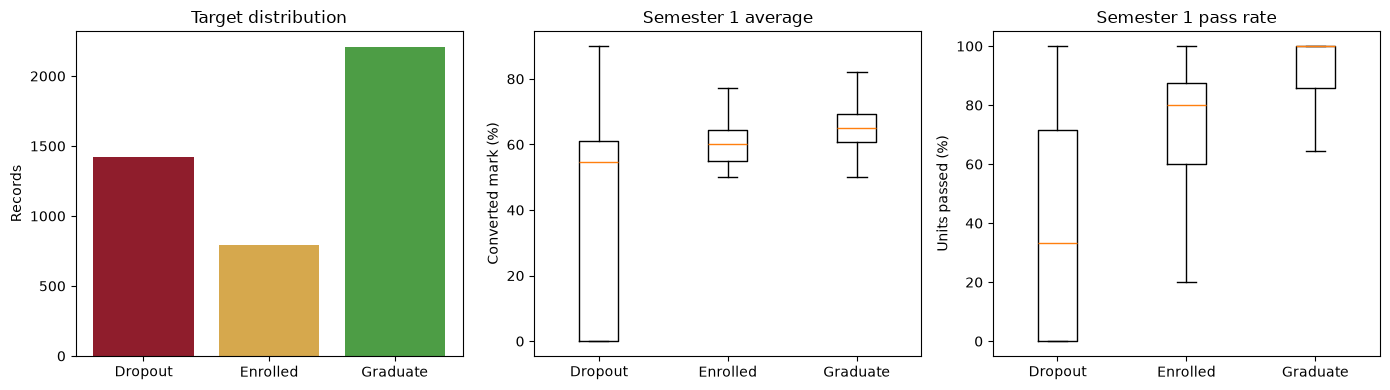

In [4]:
from src.features import engineer_semester1_features

research = engineer_semester1_features(raw, include_target=True)
order = ["Dropout", "Enrolled", "Graduate"]
colors = ["#8F1D2C", "#D6A84D", "#4D9D45"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
counts = research["Target"].value_counts().reindex(order)
axes[0].bar(order, counts, color=colors)
axes[0].set_title("Target distribution")
axes[0].set_ylabel("Records")
axes[1].boxplot([research.loc[research.Target == label, "average_mark_pct"] for label in order], tick_labels=order, showfliers=False)
axes[1].set_title("Semester 1 average")
axes[1].set_ylabel("Converted mark (%)")
axes[2].boxplot([research.loc[research.Target == label, "pass_rate"] * 100 for label in order], tick_labels=order, showfliers=False)
axes[2].set_title("Semester 1 pass rate")
axes[2].set_ylabel("Units passed (%)")
plt.tight_layout()
plt.show()

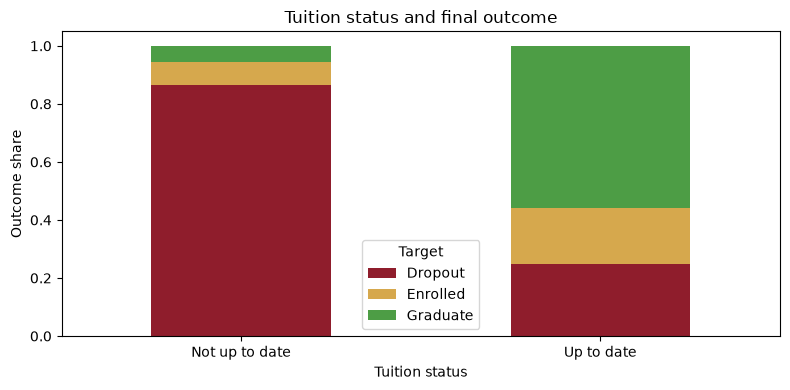

Target,Dropout,Enrolled,Graduate
tuition_up_to_date,,,
Not up to date,0.865530,0.079545,0.054924
Up to date,0.247433,0.193018,0.559548


In [5]:
fee_outcomes = pd.crosstab(
    research["tuition_up_to_date"].map({1: "Up to date", 0: "Not up to date"}),
    research["Target"],
    normalize="index",
).reindex(columns=order)
fee_outcomes.plot(kind="bar", stacked=True, color=colors, figsize=(8, 4))
plt.ylabel("Outcome share")
plt.xlabel("Tuition status")
plt.title("Tuition status and final outcome")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
fee_outcomes

## 5. Feature Engineering

The deployed UI accepts seven concepts. The saved pipeline derives `units_not_passed`, `pass_rate` and `assessments_per_unit` with divide-by-zero protection. The UCI 0–20 grade is multiplied by five for an exact 0–100 display conversion. All Semester 2, identity and sensitive/proxy fields are excluded.

In [6]:
from src.config import ENGINEERED_FEATURES, INPUT_FEATURES
from src.features import build_compact_inputs, engineer_compact_inputs

compact = build_compact_inputs(raw, include_target=False)
engineered = engineer_compact_inputs(compact)
print("Required UI inputs:", INPUT_FEATURES)
print("Engineered model features:", ENGINEERED_FEATURES)
engineered.describe().T

Required UI inputs: ['units_registered', 'units_passed', 'average_mark_pct', 'assessments_completed', 'tuition_up_to_date', 'outstanding_fee_balance', 'scholarship_support']
Engineered model features: ['units_registered', 'units_passed', 'units_not_passed', 'pass_rate', 'average_mark_pct', 'assessments_completed', 'assessments_per_unit', 'tuition_up_to_date', 'outstanding_fee_balance', 'scholarship_support']


,count,mean,std,min,25%,50%,75%,max
units_registered,4424.0,6.270570,2.480178,0.0,5.0,6.000000,7.0,26.000
units_passed,4424.0,4.706600,3.094238,0.0,3.0,5.000000,6.0,26.000
units_not_passed,4424.0,1.563969,1.980227,0.0,0.0,1.000000,2.0,9.000
pass_rate,4424.0,0.697885,0.365247,0.0,0.5,0.833333,1.0,1.000
average_mark_pct,4424.0,53.204108,24.218317,0.0,55.0,61.428571,67.0,94.375
assessments_completed,4424.0,8.299051,4.179106,0.0,6.0,8.000000,10.0,45.000
assessments_per_unit,4424.0,1.290340,0.567320,0.0,1.0,1.200000,1.6,3.500
tuition_up_to_date,4424.0,0.880651,0.324235,0.0,1.0,1.000000,1.0,1.000
outstanding_fee_balance,4424.0,0.113698,0.317480,0.0,0.0,0.000000,0.0,1.000
scholarship_support,4424.0,0.248418,0.432144,0.0,0.0,0.000000,0.0,1.000


In [7]:
feature_comparison = pd.read_csv(ROOT / "artifacts" / "feature_set_comparison.csv")
feature_comparison

,feature_set,input_count,model_feature_count,accuracy,balanced_accuracy,macro_f1,weighted_f1,dropout_recall
0,C — engineered compact inputs,7,10,0.704995,0.668943,0.662323,0.716608,0.652566
1,B — compact raw inputs,7,7,0.700193,0.662806,0.656800,0.713972,0.613842
2,A — wider leakage-safe Semester 1,13,13,0.699065,0.655892,0.651619,0.710487,0.652547


## 6. Model Building

The methodology creates one stratified 80/20 split with seed 42. Five-fold stratified cross-validation on training data compares Logistic Regression, Random Forest, Extra Trees, Support Vector Machine and Histogram Gradient Boosting. The two strongest candidates are tuned with bounded randomized searches. Run `python -m scripts.train` from the repository root to reproduce all artifacts.

In [8]:
model_comparison = pd.read_csv(ROOT / "artifacts" / "model_comparison.csv")
model_comparison[["model", "macro_f1", "balanced_accuracy", "accuracy", "weighted_f1", "dropout_recall"]]

,model,macro_f1,balanced_accuracy,accuracy,weighted_f1,dropout_recall
0,Support Vector Machine,0.663725,0.677044,0.699624,0.714628,0.623530
1,Logistic Regression,0.662323,0.668943,0.704995,0.716608,0.652566
2,Extra Trees,0.657036,0.660908,0.704711,0.712747,0.691263
3,Random Forest,0.642391,0.641779,0.702452,0.704771,0.707103
4,Histogram Gradient Boosting,0.627035,0.629680,0.679845,0.686674,0.686904


In [9]:
pd.DataFrame(RESULTS["model_selection"]["tuning"])

,model,untuned_cv_macro_f1,tuned_cv_macro_f1,improvement,best_params
0,Support Vector Machine,0.663725,0.664839,0.001114,"{""model__C"": 8.0, ""model__gamma"": ""scale""}"
1,Logistic Regression,0.662323,0.664741,0.002418,"{""model__C"": 0.1}"


## 7. Model Evaluation

Macro F1 is primary because it weights each imbalanced class equally. The final test partition is evaluated once after selection. Reported evidence includes Accuracy, Balanced Accuracy, Macro and Weighted F1, per-class metrics, confusion matrix, log loss and multiclass ROC-AUC. Probability calibration is selected through nested training cross-validation.

In [10]:
metrics = RESULTS["holdout"]
pd.Series({name: metrics[name] for name in [
    "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1",
    "log_loss", "multiclass_brier", "roc_auc_ovr_weighted",
]}, name="Final holdout")

accuracy                0.720904
balanced_accuracy       0.628398
macro_f1                0.629717
weighted_f1             0.709025
log_loss                0.673849
multiclass_brier        0.377990
roc_auc_ovr_weighted    0.866953
Name: Final holdout, dtype: float64

In [11]:
report = pd.DataFrame(metrics["classification_report"]).T
report.loc[["Dropout", "Enrolled", "Graduate"], ["precision", "recall", "f1-score", "support"]]

,precision,recall,f1-score,support
Dropout,0.734043,0.728873,0.731449,284.0
Enrolled,0.381356,0.283019,0.324910,159.0
Graduate,0.795876,0.873303,0.832794,442.0


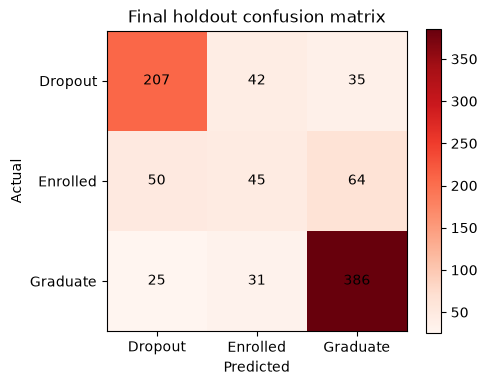

,Dropout,Enrolled,Graduate
Dropout,207,42,35
Enrolled,50,45,64
Graduate,25,31,386


In [12]:
matrix = pd.DataFrame(metrics["confusion_matrix"], index=metrics["classes"], columns=metrics["classes"])
fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(matrix, cmap="Reds")
for row in range(3):
    for column in range(3):
        ax.text(column, row, matrix.iloc[row, column], ha="center", va="center")
ax.set_xticks(range(3), matrix.columns)
ax.set_yticks(range(3), matrix.index)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Final holdout confusion matrix")
plt.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()
matrix

## 8. Results Interpretation & Insights

Global permutation importance measures the decrease in holdout Macro F1 when an input is shuffled. It describes model reliance, not causation. Individual portal explanations compare the estimate with research-cohort medians. The Enrolled class remains the most difficult and is reported as a limitation.

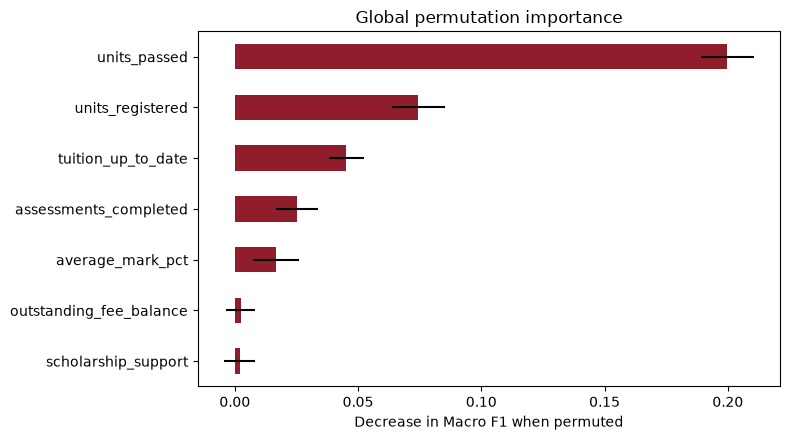

,feature,importance,std
0,units_passed,0.199735,0.010697
1,units_registered,0.074401,0.010721
2,tuition_up_to_date,0.045259,0.007238
3,assessments_completed,0.025206,0.008490
4,average_mark_pct,0.016585,0.009339
5,outstanding_fee_balance,0.002348,0.005848
6,scholarship_support,0.001967,0.006276


In [13]:
importance = pd.read_csv(ROOT / "artifacts" / "feature_importance.csv").sort_values("importance")
importance.plot.barh(x="feature", y="importance", xerr="std", legend=False, color="#8F1D2C", figsize=(8, 4.5))
plt.xlabel("Decrease in Macro F1 when permuted")
plt.ylabel("")
plt.title("Global permutation importance")
plt.tight_layout()
plt.show()
importance.sort_values("importance", ascending=False)

## 9. Deployment

The Streamlit portal has four concise pages: Dashboard, Student Assessment, Cohort Analytics and Model Performance. `START_EDUPULSE.bat` performs setup and trains only when required; `RUN_EDUPULSE.bat` fast-starts existing artifacts. The complete sklearn pipeline includes feature engineering, imputation, scaling, classification and calibration.

In [14]:
from src.features import build_assessment_row
from src.inference import load_model, support_priority

model = load_model()
demo = build_assessment_row(
    units_registered=6,
    units_passed=2,
    average_mark_pct=41,
    assessments_completed=3,
    tuition_up_to_date=0,
    outstanding_fee_balance=1,
    scholarship_support=0,
)
probabilities = dict(zip(model.classes_, model.predict_proba(demo)[0]))
{
    "probabilities": probabilities,
    "support_priority": support_priority(probabilities["Dropout"], RESULTS["risk_bands"]),
}

{'probabilities': {'Dropout': np.float64(0.913954168995079),
  'Enrolled': np.float64(0.053009401744287185),
  'Graduate': np.float64(0.03303642926063393)},
 'support_priority': 'Higher Priority'}

## 10. Conclusion

EduPulse AI is a reproducible, leakage-safe and transparent academic prototype. The compact engineered feature set retained the strongest validation trade-off, the final model provides calibrated estimated probabilities, and every intervention remains supportive and human-reviewed. The Portuguese research source is not evidence of Kabarak validity; governance, privacy review, local validation, fairness testing and prospective monitoring are required before operational use.